### Задание 1

In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import pingouin as pg
from scipy.stats import chi2_contingency, chi2 
import numpy as np
from scipy import stats

In [2]:
auth_data = pd.read_csv('problem1-auth_data.csv', sep=';')

In [3]:
auth_data['auth_ts'] = pd.to_datetime(auth_data['auth_ts'], unit='s')

In [4]:
auth_data.head()

,auth_ts,uid
0,1998-11-18 09:43:43,1
1,1999-07-22 22:38:09,2
2,1999-07-25 16:46:46,2
3,1999-07-31 03:50:15,2
4,1999-08-05 17:49:39,2


In [5]:
auth_data.dtypes

auth_ts    datetime64[ns]
uid                 int64
dtype: object

In [6]:
auth_data.isna().sum()

auth_ts    0
uid        0
dtype: int64

In [7]:
reg_data = pd.read_csv('problem1-reg_data.csv', sep=';')

In [8]:
reg_data['reg_ts'] = pd.to_datetime(reg_data['reg_ts'], unit='s')

In [9]:
reg_data.head()

,reg_ts,uid
0,1998-11-18 09:43:43,1
1,1999-07-22 22:38:09,2
2,2000-01-13 22:27:27,3
3,2000-05-28 14:19:01,4
4,2000-09-16 11:21:53,5


In [10]:
reg_data.dtypes

reg_ts    datetime64[ns]
uid                int64
dtype: object

In [11]:
reg_data.isna().sum()

reg_ts    0
uid       0
dtype: int64

In [12]:
reg_data_copy = reg_data.copy()

In [13]:
auth_data_copy = auth_data.copy()

In [21]:
last_date = reg_data_copy['reg_ts'].max()
last_date

Timestamp('2020-09-23 15:17:24')

In [15]:
#переменная, чтобы отфильтровать данные по количеству дней
last_n_days = 15

In [16]:
start_date = last_date - pd.Timedelta(days=last_n_days)

In [17]:
reg_data_copy = reg_data_copy[reg_data_copy['reg_ts'] >= start_date]

In [20]:
reg_data_copy.head()

,reg_ts,uid
975636,2020-09-08 15:18:02,1083545
975637,2020-09-08 15:18:56,1083546
975638,2020-09-08 15:19:49,1083547
975639,2020-09-08 15:20:43,1083548
975640,2020-09-08 15:21:37,1083550


In [22]:
df['days_since_reg'] = ((df['auth_ts'].astype('datetime64[D]') - 
                        df['reg_ts'].astype('datetime64[D]')).dt.days).fillna(0)

In [23]:
df['reg_ts_day'] = df['reg_ts'].astype('datetime64[D]').dt.date

In [24]:
df.head()

,reg_ts,uid,auth_ts,days_since_reg,reg_ts_day
0,2020-09-08 15:18:02,1083545,2020-09-08 15:18:02,0,2020-09-08
1,2020-09-08 15:18:56,1083546,2020-09-08 15:18:56,0,2020-09-08
2,2020-09-08 15:19:49,1083547,2020-09-08 15:19:49,0,2020-09-08
3,2020-09-08 15:20:43,1083548,2020-09-08 15:20:43,0,2020-09-08
4,2020-09-08 15:20:43,1083548,2020-09-12 08:54:15,3,2020-09-08


In [25]:
df_pivot = df.groupby(['reg_ts_day', 'days_since_reg']).agg(n_customers=('uid', 'nunique')).reset_index()

In [26]:
df_pivot.head()

,reg_ts_day,days_since_reg,n_customers
0,2020-09-08,0,582
1,2020-09-08,1,24
2,2020-09-08,2,26
3,2020-09-08,3,24
4,2020-09-08,4,38


In [27]:
cohort_pivot = df_pivot.pivot_table(index='reg_ts_day', columns='days_since_reg', values='n_customers')

In [28]:
cohort_pivot.head()

days_since_reg,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
reg_ts_day,,,,,,,,,,,,,,,
2020-09-08,582.0,24.0,26.0,24.0,38.0,48.0,59.0,22.0,37.0,33.0,33.0,46.0,33.0,28.0,20.0
2020-09-09,1607.0,47.0,66.0,84.0,106.0,95.0,107.0,75.0,67.0,77.0,65.0,93.0,62.0,70.0,13.0
2020-09-10,1609.0,69.0,64.0,78.0,94.0,107.0,114.0,85.0,71.0,86.0,85.0,84.0,78.0,16.0,NaN
2020-09-11,1612.0,49.0,70.0,89.0,90.0,85.0,137.0,68.0,69.0,81.0,92.0,70.0,24.0,NaN,NaN
2020-09-12,1614.0,57.0,79.0,68.0,91.0,96.0,119.0,68.0,89.0,88.0,76.0,11.0,NaN,NaN,NaN


In [29]:
cohort_size = cohort_pivot.iloc[:, 0]

In [30]:
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

In [31]:
retention_matrix.head()

days_since_reg,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
reg_ts_day,,,,,,,,,,,,,,,
2020-09-08,1.0,0.041237,0.044674,0.041237,0.065292,0.082474,0.101375,0.037801,0.063574,0.056701,0.056701,0.079038,0.056701,0.048110,0.034364
2020-09-09,1.0,0.029247,0.041070,0.052271,0.065961,0.059116,0.066584,0.046671,0.041693,0.047915,0.040448,0.057872,0.038581,0.043559,0.008090
2020-09-10,1.0,0.042884,0.039776,0.048477,0.058421,0.066501,0.070851,0.052828,0.044127,0.053449,0.052828,0.052206,0.048477,0.009944,NaN
2020-09-11,1.0,0.030397,0.043424,0.055211,0.055831,0.052730,0.084988,0.042184,0.042804,0.050248,0.057072,0.043424,0.014888,NaN,NaN
2020-09-12,1.0,0.035316,0.048947,0.042131,0.056382,0.059480,0.073730,0.042131,0.055143,0.054523,0.047088,0.006815,NaN,NaN,NaN


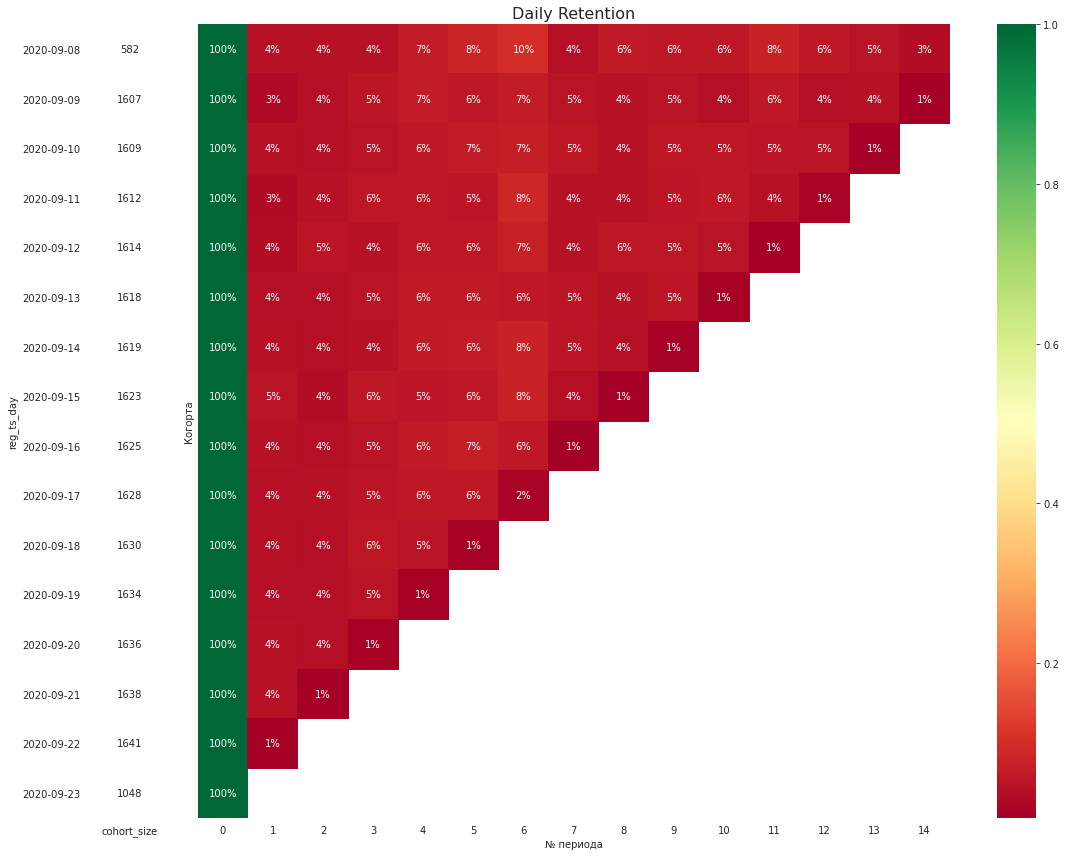

In [32]:
 with sns.axes_style("white"):
        fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})
        sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1])
        ax[1].set_title('Daily Retention', fontsize=16)
        ax[1].set(xlabel='№ периода', ylabel='Когорта')
        
        cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
        white_cmap = mcolors.ListedColormap(['white'])
        sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])
        
        fig.tight_layout()
        plt.show()

### Итоговая функция

In [33]:
def retention_n_day(reg_data, auth_data, last_n_days = 15):
    reg_data_copy = reg_data.copy()
    auth_data_copy = auth_data.copy()
    auth_data_copy['auth_ts'] = pd.to_datetime(auth_data_copy['auth_ts'], unit='s')
    reg_data_copy['reg_ts'] = pd.to_datetime(reg_data_copy['reg_ts'], unit='s')
    last_date = reg_data_copy['reg_ts'].max()
    start_date = last_date - pd.Timedelta(days=last_n_days)
    reg_data_copy = reg_data_copy[reg_data_copy['reg_ts'] >= start_date]
    df = reg_data_copy.merge(auth_data_copy, on='uid', how='left')
    df['days_since_reg'] = ((df['auth_ts'].astype('datetime64[D]') - 
                        df['reg_ts'].astype('datetime64[D]')).dt.days).fillna(0)
    df['reg_ts_day'] = df['reg_ts'].astype('datetime64[D]').dt.date
    df_pivot = df.groupby(['reg_ts_day', 'days_since_reg']).agg(n_customers=('uid', 'nunique')).reset_index()
    cohort_pivot = df_pivot.pivot_table(index='reg_ts_day', columns='days_since_reg', values='n_customers')
    cohort_size = cohort_pivot.iloc[:, 0]
    retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
    with sns.axes_style("white"):
        fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})
        sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1])
        ax[1].set_title('Daily Retention', fontsize=16)
        ax[1].set(xlabel='№ периода', ylabel='Когорта')
        
        cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
        white_cmap = mcolors.ListedColormap(['white'])
        sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])
        
        fig.tight_layout()
        plt.show()
   
    return retention_matrix

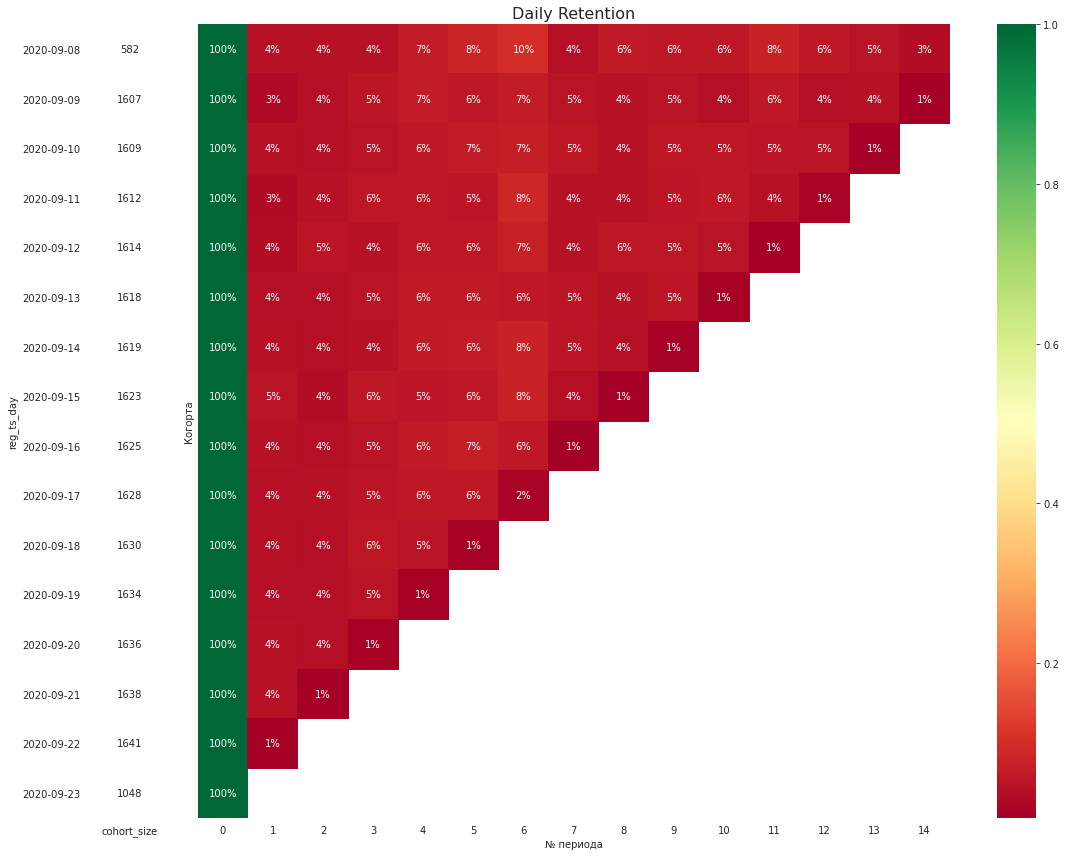

days_since_reg,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
reg_ts_day,,,,,,,,,,,,,,,
2020-09-08,1.0,0.041237,0.044674,0.041237,0.065292,0.082474,0.101375,0.037801,0.063574,0.056701,0.056701,0.079038,0.056701,0.048110,0.034364
2020-09-09,1.0,0.029247,0.041070,0.052271,0.065961,0.059116,0.066584,0.046671,0.041693,0.047915,0.040448,0.057872,0.038581,0.043559,0.008090
2020-09-10,1.0,0.042884,0.039776,0.048477,0.058421,0.066501,0.070851,0.052828,0.044127,0.053449,0.052828,0.052206,0.048477,0.009944,NaN
2020-09-11,1.0,0.030397,0.043424,0.055211,0.055831,0.052730,0.084988,0.042184,0.042804,0.050248,0.057072,0.043424,0.014888,NaN,NaN
2020-09-12,1.0,0.035316,0.048947,0.042131,0.056382,0.059480,0.073730,0.042131,0.055143,0.054523,0.047088,0.006815,NaN,NaN,NaN
2020-09-13,1.0,0.040173,0.039555,0.046354,0.061187,0.063659,0.059951,0.050680,0.042027,0.050680,0.012361,NaN,NaN,NaN,NaN
2020-09-14,1.0,0.043854,0.039531,0.044472,0.062384,0.064855,0.076590,0.050031,0.037678,0.010500,NaN,NaN,NaN,NaN,NaN
2020-09-15,1.0,0.046827,0.036969,0.057917,0.051756,0.059766,0.077634,0.038201,0.006161,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-16,1.0,0.041231,0.037538,0.046769,0.063385,0.070769,0.059077,0.006769,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
retention_n_day(reg_data, auth_data, last_n_days = 15)

### Задание 2

По данным мы видим, что ARPU в тестовой группе выше на 5%, при этом количество платящих выше в контрольной группе.
Из-за чего есть сомнения к данным, так как средняя выручка растет, а конверсия в оплату падает, что не совсем логично. 
Поэтому я бы посмотрела на следующие метрики:
1. Конверсия в оплату. Понять правда ли больше или меньше людей стали платить.
2. Средний чек на платящего пользователя. Возможно люди стали больше платить.
3. Посмотреть на распределение выручки. Можно построить boxplot и увидеть есть ли выбросы. Могли ли, например, 2 крупные покупки повлиять на средний чек.

Также посмотрела на статистическую значимость.
- Для конверсии в оплату использовала бы Хи-квадрат. Так как у нас 2 категории пользователей: платил/не платил.
- Для среднего чека платящих использовать T-критерий

In [3]:
data = pd.read_csv('Проект_1_Задание_2.csv', sep=';')

In [4]:
data.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [7]:
CR_control = round(1928/202103 * 100, 2)
CR_control

0.95

In [8]:
CR_test = round(1805/202667 * 100, 2)
CR_test

0.89

В тестовой группе по сравнению с контрольной конверсия в оплату упала на 6%. Используя Хи-квадрат проверю является ли это статистически значимо.

In [12]:
data["is_paying"] = data.revenue > 0
data.head()

,user_id,revenue,testgroup,is_paying
0,1,0,b,False
1,2,0,a,False
2,3,0,a,False
3,4,0,b,False
4,5,0,b,False


In [13]:
stat, p, dof, expected = chi2_contingency(pd.crosstab(data.testgroup, data.is_paying))

In [14]:
stat, p

(4.374729521260405, 0.03647561892312613)

In [15]:
# Интерпретируем результат:
prob = 0.95
alpha = 1.0 - prob
if p <= alpha:
    print('Отклоняем H0')
else:
    print('Не отклоняем H0')

Отклоняем H0


По результатам Хи-квадрата можем сделать вывод, что снижение конверсии в оплату в тестовой группе является статистически значимым.

Посмотрим на boxplot, есть ли выбросы по средним чекам в группах.

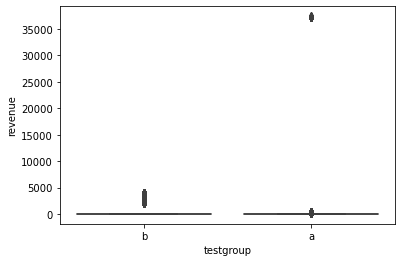

In [16]:
sns.boxplot(data=data, x="testgroup", y="revenue")

На графике видно различие в поведении платящих пользователей:
В контрольной группе А выручка сильно сегментирована: пользователи либо покупают в районе от 0 до 3000, либо совершают крупные покупки от 35000.

В тестовой группе B отсутствуют пользователи с крупными покупками. Вместо этого все платящие пользователи совершают покупки в диапазоне 2000–5000.

Далее посмотрим является ли различие в средних чеках статистически значимо по всем пользователям(ARPU) и по платящим(ARPPU).

In [19]:
control_arpu = data.query('testgroup == "a"').revenue
control_arpu.head()

1     0
2     0
9     0
10    0
11    0
Name: revenue, dtype: int64

In [20]:
test_arpu = data.query('testgroup == "b"').revenue
test_arpu.head()

0    0
3    0
4    0
5    0
6    0
Name: revenue, dtype: int64

In [21]:
pg.ttest(control_arpu, test_arpu)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.623488,240991.130782,two-sided,0.532965,"[-5.54, 2.87]",0.001962,0.004,0.095694


P-value сильно близок к 0.5, поэтому различия статистически не значимы. Не можем говорить о том, что доход на пользователя вырос.

In [23]:
control_arppu = data.query('testgroup == "a" and revenue > 0').revenue
control_arppu.head()

72       351
341      290
385      250
416    37324
712      255
Name: revenue, dtype: int64

In [24]:
test_arppu = data.query('testgroup == "b" and revenue >0').revenue
test_arppu.head()

160    3797
377    3768
386    3527
551    2038
913    3902
Name: revenue, dtype: int64

In [25]:
pg.ttest(control_arppu, test_arppu)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-1.64463,1943.481522,two-sided,0.100208,"[-744.7, 65.38]",0.052132,0.142,0.356381


По ARPPU различия также статистически не значимы(p = 0.1)

#### Выводы
1. Отсутствие крупных пользователей.
В тестовой группе отсутствует сегмент пользователей, которые совершают крупные покупки.
2. Снижение вовлеченности в оплату.
В тестовой группе наблюдается снижение конверсии в оплату, что говорит о том, что мы могли потерять какую-то ценность для пользователя или усложнили процесс оплаты.
3. Нестабильность.
Рост ARPU в тесте происходит засчет увеличения чека некрупных(средних) пользователей, что не перекрывает потерю крупных пользователей и падение конверсии статистически значимым образом.

##### Итого:
По результам A/B теста я бы не раскатывала его на всех. Я бы рекомендовала исследовать, почему пропали крупные платежи. Также попробовать предложить гипотезу, которая не убирала бы крупные чеки от пользователей и при этом повышала бы средний чек "средних" пользователей.


### Задание 3

#### 1 часть

Метрики для оценки результатов последнего события:

1. DAU до события / во время / после события. Для того, чтобы отслеживать активность игроков.
2. Конверсия из DAU в сыгравших хотя бы один уровень, чтобы увидеть связанно ли именно с событием.
3. Retention участников события ежедневный. Увидеть, насколько игроки вовлечены.
4. Посмотреть на воронку по прохождению уровней, чтобы отслеживать прогресс события у игроков:
- начали
- забросили
- дошли до финала
- получили награду
5. Среднее количество уровней на пользователей. Насколько вовлеченны игроки в событие.
6. Конверсия в оплату и средний чек платящих. Если причина запуска события - увеличение прибыли.
7. Доля ресурсов, полученных из события от всего периода игры. Сохранен ли баланс игры после события.
8. Сравнить с прошлым событием по DAU, конверсию из DAU в сыгравших хотя бы один уровень, средний чек и долю ресурсов.

#### 2 часть

В случае усложнения механики игры, я бы к метрикам из 1 части добавила бы:

1. Churn Rate участников события ежедневный, чтобы отслеживать как много игроков перестают играть
2. Обращения в поддержку по событию
3. Долю успешных попыток
4. Долю откатов 
5. Изменение рейтинга игры в сторах после события